In [31]:
from pathlib import Path
import pandas as pd

data_dir = Path(".")
if not (data_dir / "customer_orders.csv").exists():
    data_dir = Path("BIG DATA/DaniPizza")

customer_orders = pd.read_csv(data_dir / "customer_orders.csv")
pizza_names = pd.read_csv(data_dir / "pizza_names.csv")
pizza_recipes = pd.read_csv(data_dir / "pizza_recipes.csv")
pizza_toppings = pd.read_csv(data_dir / "pizza_toppings.csv")
runners = pd.read_csv(data_dir / "runners.csv")
runner_orders = pd.read_csv(data_dir / "runner_orders.csv")

customer_orders.head()

,order_id,customer_id,pizza_id,exclusions,extras,order_date
0,2481,500,2,NaN,NaN,2025-02-21 16:06:46
1,1897,269,6,NaN,NaN,2025-08-12 08:27:50
2,1842,59,7,NaN,NaN,2024-12-23 20:50:23
3,1869,710,6,NaN,NaN,2025-01-31 09:16:49
4,2384,189,3,NaN,NaN,2024-11-30 17:35:37


In [32]:
runner_orders['cancellation'].unique()

array([nan, 'address issue', 'custmer_no_sho', 'runner sick',
       'customer no show', 'order late', 'restaurant_cancelled',
       'runner_unavailable'], dtype=object)

In [33]:
runners

,runner_id,registration_date
0,1,2021-01-03
1,2,2021-01-10
2,3,2021-01-17
3,4,2021-01-24
4,5,2021-01-31
5,6,2021-02-07
6,7,2021-02-14
7,8,2021-02-21
8,9,2021-02-28
9,10,2021-03-07


In [34]:
import sqlite3

with sqlite3.connect(":memory:") as conn:
    customer_orders.to_sql("customer_orders", conn, index=False, if_exists="replace")
    pizza_names.to_sql("pizza_names", conn, index=False, if_exists="replace")

    query = """
    SELECT
        co.order_id,
        co.customer_id,
        co.pizza_id,
        pn.pizza_name,
        co.exclusions,
        co.extras,
        co.order_date
    FROM customer_orders AS co
    LEFT JOIN pizza_names AS pn
        ON co.pizza_id = pn.pizza_id
    """

    orders_with_pizza_names = pd.read_sql_query(query, conn)

orders_with_pizza_names.head()

,order_id,customer_id,pizza_id,pizza_name,exclusions,extras,order_date
0,2481,500,2,Vegetarian,None,None,2025-02-21 16:06:46
1,1897,269,6,Pepperoni,None,None,2025-08-12 08:27:50
2,1842,59,7,Vegan Veggie,None,None,2024-12-23 20:50:23
3,1869,710,6,Pepperoni,None,None,2025-01-31 09:16:49
4,2384,189,3,Meat Lovers,None,None,2024-11-30 17:35:37


In [35]:
recipe_toppings = (
    pizza_recipes.assign(topping_id=pizza_recipes["toppings"].str.split(","))
    .explode("topping_id")
    .drop(columns="toppings")
)
recipe_toppings["topping_id"] = recipe_toppings["topping_id"].astype(int)

with sqlite3.connect(":memory:") as conn:
    orders_with_pizza_names.to_sql("orders_with_pizza_names", conn, index=False, if_exists="replace")
    recipe_toppings.to_sql("recipe_toppings", conn, index=False, if_exists="replace")
    pizza_toppings.to_sql("pizza_toppings", conn, index=False, if_exists="replace")

    detail_query = """
    SELECT
        o.order_id,
        o.customer_id,
        o.pizza_id,
        o.pizza_name,
        rt.topping_id,
        pt.topping_name,
        o.exclusions,
        o.extras,
        o.order_date
    FROM orders_with_pizza_names AS o
    LEFT JOIN recipe_toppings AS rt
        ON o.pizza_id = rt.pizza_id
    LEFT JOIN pizza_toppings AS pt
        ON rt.topping_id = pt.topping_id
    """

    orders_toppings_detail = pd.read_sql_query(detail_query, conn)

    summary_query = """
    SELECT
        o.order_id,
        o.customer_id,
        o.pizza_id,
        o.pizza_name,
        GROUP_CONCAT(pt.topping_name, ', ') AS recipe_toppings,
        o.exclusions,
        o.extras,
        o.order_date
    FROM orders_with_pizza_names AS o
    LEFT JOIN recipe_toppings AS rt
        ON o.pizza_id = rt.pizza_id
    LEFT JOIN pizza_toppings AS pt
        ON rt.topping_id = pt.topping_id
    GROUP BY
        o.order_id,
        o.customer_id,
        o.pizza_id,
        o.pizza_name,
        o.exclusions,
        o.extras,
        o.order_date
    """

    orders_with_pizza_details = pd.read_sql_query(summary_query, conn)

orders_with_pizza_details.head()

,order_id,customer_id,pizza_id,pizza_name,recipe_toppings,exclusions,extras,order_date
0,1001,96,4,BBQ Chicken,"Tomato Sauce, Mozzarella, Chicken, BBQ Sauce",None,11,2025-03-15 13:20:16
1,1002,658,2,Vegetarian,"Tomato Sauce, Mozzarella, Mushroom, Onion, Bel...",None,None,2025-04-30 17:15:29
2,1003,677,3,Meat Lovers,"Tomato Sauce, Mozzarella, Pepperoni, Bacon, Beef",None,None,2025-04-05 20:41:21
3,1004,121,2,Vegetarian,"Tomato Sauce, Mozzarella, Mushroom, Onion, Bel...",4,None,2024-11-28 09:00:40
4,1004,121,5,Hawaiian,"Tomato Sauce, Mozzarella, Olives, Pineapple",None,"10,14",2024-11-28 09:00:40


# EDA

In [36]:
customer_orders.info()
customer_orders.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2101 entries, 0 to 2100
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   order_id     2101 non-null   int64 
 1   customer_id  2101 non-null   int64 
 2   pizza_id     2101 non-null   int64 
 3   exclusions   629 non-null    object
 4   extras       666 non-null    object
 5   order_date   2101 non-null   object
dtypes: int64(3), object(3)
memory usage: 98.6+ KB


,order_id,customer_id,pizza_id
count,2101.000000,2101.000000,2101.000000
mean,1755.314612,419.000000,3.834841
std,429.404435,240.507125,1.847996
min,1001.000000,1.000000,1.000000
25%,1390.000000,207.000000,2.000000
50%,1756.000000,453.000000,4.000000
75%,2122.000000,654.000000,6.000000
max,2500.000000,798.000000,7.000000


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

## Runner delivery analysis

In [38]:
with sqlite3.connect(":memory:") as conn:
    runner_orders.to_sql("runner_orders", conn, index=False, if_exists="replace")
    runners.to_sql("runners", conn, index=False, if_exists="replace")

    runner_query = """
    SELECT
        ro.order_id,
        ro.runner_id,
        r.registration_date,
        ro.pickup_time,
        ro.distance,
        ro.duration,
        ro.cancellation
    FROM runner_orders AS ro
    LEFT JOIN runners AS r
        ON ro.runner_id = r.runner_id
    """

    runner_delivery_details = pd.read_sql_query(runner_query, conn)

runner_delivery_details["registration_date"] = pd.to_datetime(runner_delivery_details["registration_date"])
runner_delivery_details["pickup_time"] = pd.to_datetime(runner_delivery_details["pickup_time"], errors="coerce")
runner_delivery_details["duration_minutes"] = (
    runner_delivery_details["duration"]
    .astype("string")
    .str.extract(r"(\d+)", expand=False)
    .astype("float")
)
runner_delivery_details["distance_km"] = (
    runner_delivery_details["distance"]
    .astype("string")
    .str.extract(r"([\d.]+)", expand=False)
    .astype("float")
)
runner_delivery_details["cancellation_clean"] = (
    runner_delivery_details["cancellation"]
    .fillna("completed")
    .replace({"custmer_no_sho": "customer no show"})
)
runner_delivery_details["is_cancelled"] = runner_delivery_details["cancellation_clean"] != "completed"
runner_delivery_details["runner_tenure_days"] = (
    runner_delivery_details["pickup_time"] - runner_delivery_details["registration_date"]
).dt.days
runner_delivery_details["runner_tenure_years"] = runner_delivery_details["runner_tenure_days"] / 365.25

def assign_time_block(pickup_time):
    if pd.isna(pickup_time):
        return "Sin pickup"
    hour = pickup_time.hour
    if 6 <= hour < 12:
        return "Mañana (6am-12pm)"
    if 12 <= hour < 18:
        return "Tarde (12pm-6pm)"
    return "Noche (6pm-6am)"

runner_delivery_details["time_block"] = runner_delivery_details["pickup_time"].apply(assign_time_block)

runner_delivery_details.head()

,order_id,runner_id,registration_date,pickup_time,distance,duration,cancellation,duration_minutes,distance_km,cancellation_clean,is_cancelled,runner_tenure_days,runner_tenure_years,time_block
0,1001,10,2021-03-07,2025-03-15 13:33:16,1.3km,8 minutes,None,8.0,1.3,completed,False,1469.0,4.021903,Tarde (12pm-6pm)
1,1002,15,2021-04-11,2025-04-30 17:28:29,5.0km,22 minutes,None,22.0,5.0,completed,False,1480.0,4.052019,Tarde (12pm-6pm)
2,1003,15,2021-04-11,2025-04-05 20:54:21,4.6km,13 minutes,None,13.0,4.6,completed,False,1455.0,3.983573,Noche (6pm-6am)
3,1004,15,2021-04-11,2024-11-28 09:13:40,1.6 km,8 minutes,None,8.0,1.6,completed,False,1327.0,3.633128,Mañana (6am-12pm)
4,1005,8,2021-02-21,2025-06-07 14:54:26,2.1km,12 minutes,None,12.0,2.1,completed,False,1567.0,4.290212,Tarde (12pm-6pm)


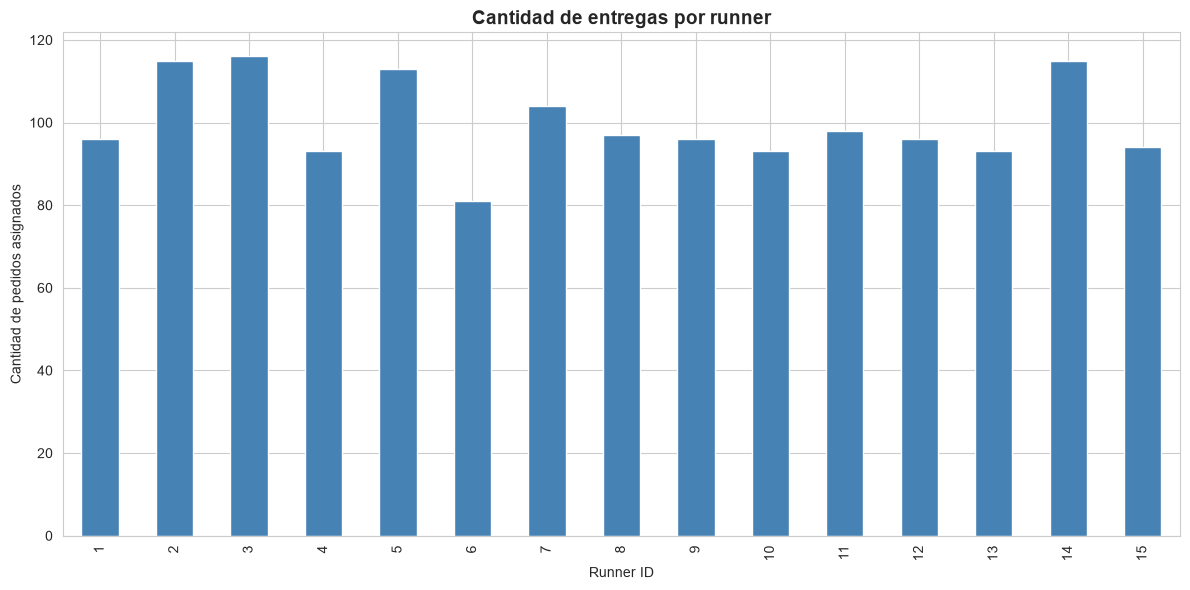

In [39]:
# 1. Cantidad de entregas por runner
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
runner_delivery_details["runner_id"].value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Cantidad de entregas por runner", fontsize=14, fontweight="bold")
ax.set_xlabel("Runner ID")
ax.set_ylabel("Cantidad de pedidos asignados")
plt.tight_layout()
plt.show()

,runner_id,avg_duration_minutes,total_deliveries
11,12,18.202128,96
0,1,16.722222,93
10,11,16.677419,96
2,3,16.209091,115
12,13,16.193182,91
9,10,16.160920,89
3,4,16.141176,90
14,15,16.034884,89
8,9,15.833333,87
7,8,15.793478,92


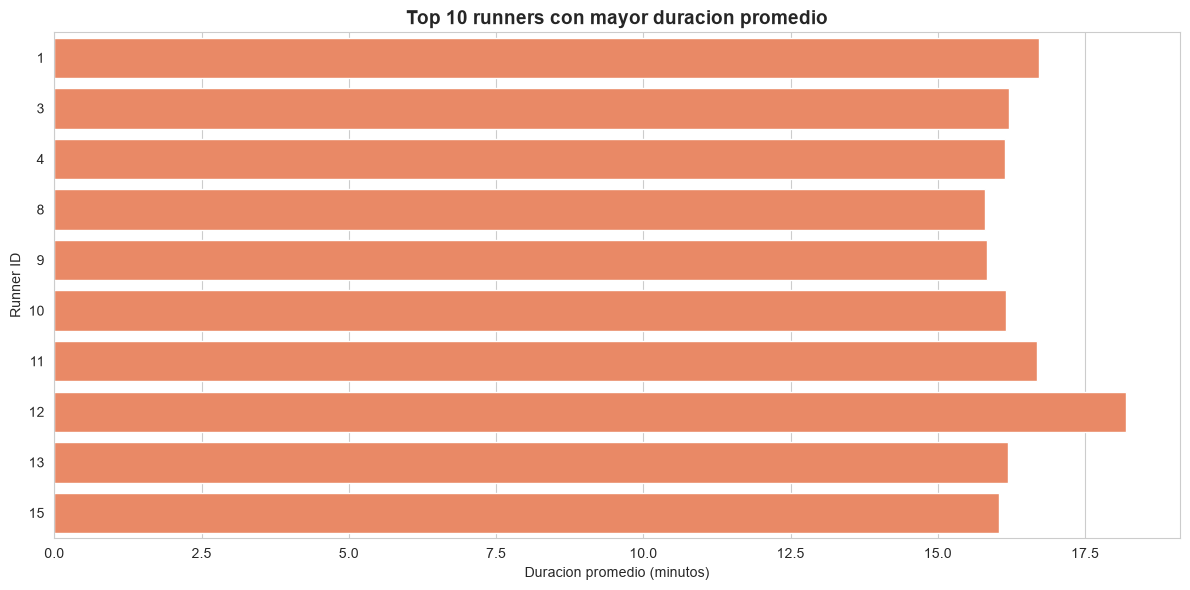

In [40]:
# 2. Top 10 runners que mas tardan en entregar pedidos
completed_deliveries = runner_delivery_details[~runner_delivery_details["is_cancelled"]].copy()

top_10_slowest_runners = (
    completed_deliveries.groupby("runner_id", as_index=False)
    .agg(
        avg_duration_minutes=("duration_minutes", "mean"),
        total_deliveries=("order_id", "count"),
    )
    .sort_values("avg_duration_minutes", ascending=False)
    .head(10)
)

display(top_10_slowest_runners)

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
sns.barplot(data=top_10_slowest_runners, x="avg_duration_minutes", y="runner_id", orient="h", ax=ax, color="coral")
ax.set_title("Top 10 runners con mayor duracion promedio", fontsize=14, fontweight="bold")
ax.set_xlabel("Duracion promedio (minutos)")
ax.set_ylabel("Runner ID")
plt.tight_layout()
plt.show()

,runner_tenure_years,duration_minutes
runner_tenure_years,1.000000,-0.002589
duration_minutes,-0.002589,1.000000


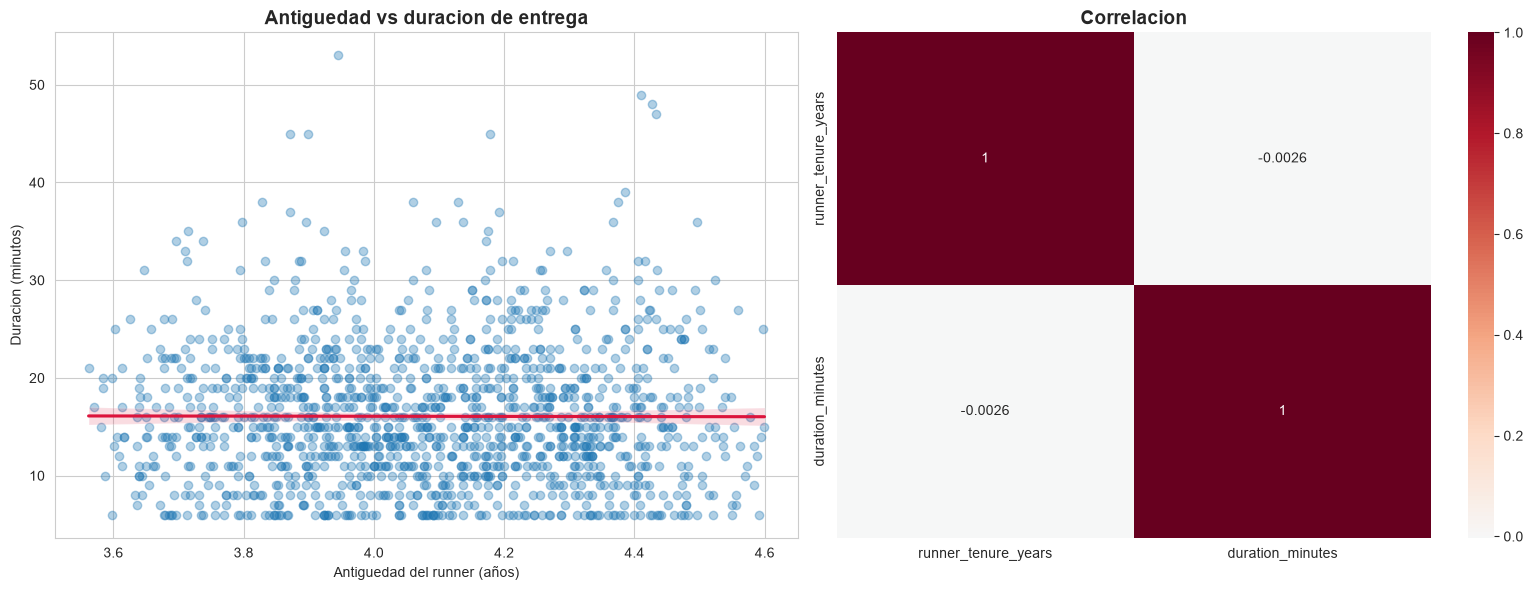

In [41]:
# 3. Relacion entre antiguedad del runner y duracion de entrega
correlation_data = completed_deliveries[["runner_tenure_years", "duration_minutes"]].dropna()
runner_tenure_duration_corr = correlation_data.corr()

display(runner_tenure_duration_corr)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.regplot(
    data=correlation_data,
    x="runner_tenure_years",
    y="duration_minutes",
    scatter_kws={"alpha": 0.35},
    line_kws={"color": "crimson"},
    ax=axes[0],
)
axes[0].set_title("Antiguedad vs duracion de entrega", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Antiguedad del runner (años)")
axes[0].set_ylabel("Duracion (minutos)")

sns.heatmap(runner_tenure_duration_corr, annot=True, cmap="RdBu_r", center=0, ax=axes[1])
axes[1].set_title("Correlacion", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

,cancellation,cantidad
0,completed,1450
1,customer no show,16
2,address issue,13
3,runner sick,7
4,order late,7
5,runner_unavailable,5
6,restaurant_cancelled,2


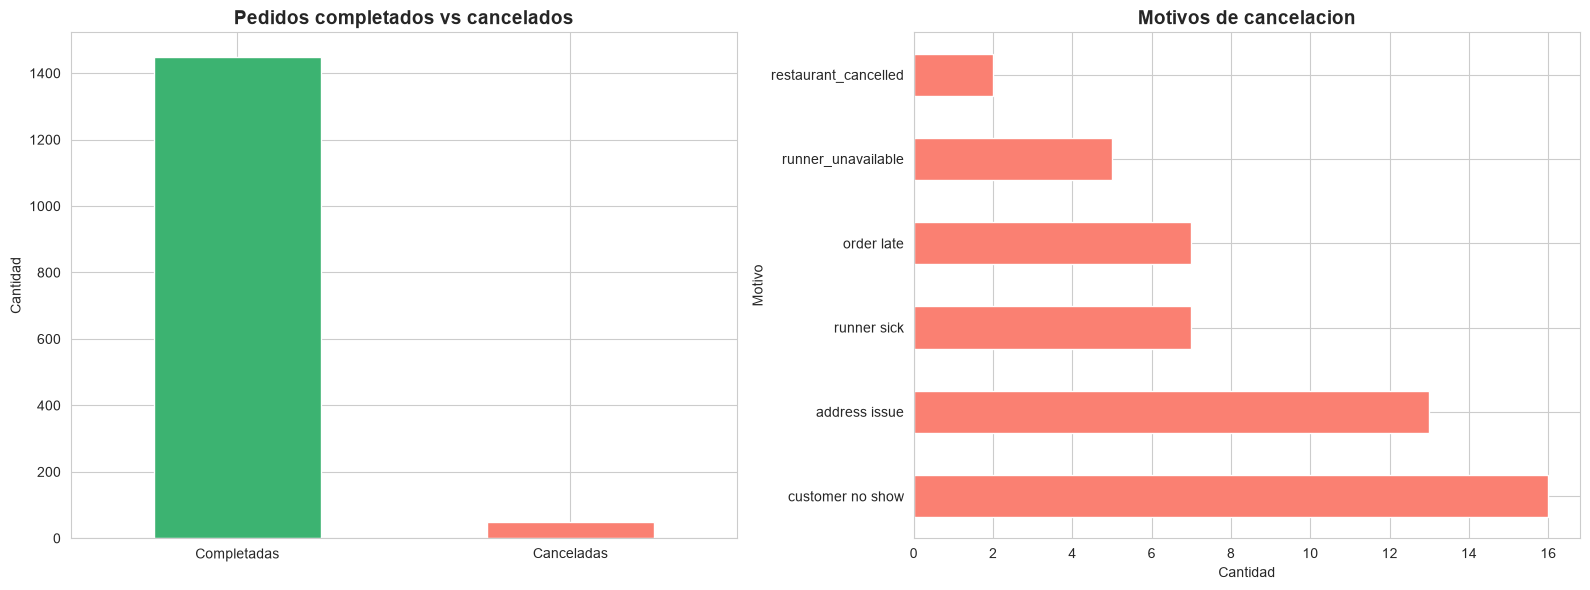

In [42]:
# Graficas de cancelaciones
cancellation_counts = runner_delivery_details["cancellation_clean"].value_counts()
display(cancellation_counts.rename_axis("cancellation").reset_index(name="cantidad"))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
runner_delivery_details["is_cancelled"].value_counts().rename({False: "Completadas", True: "Canceladas"}).plot(
    kind="bar",
    ax=axes[0],
    color=["mediumseagreen", "salmon"],
)
axes[0].set_title("Pedidos completados vs cancelados", fontsize=14, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Cantidad")
axes[0].tick_params(axis="x", rotation=0)

cancellation_counts.drop(labels="completed", errors="ignore").plot(kind="barh", ax=axes[1], color="salmon")
axes[1].set_title("Motivos de cancelacion", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Cantidad")
axes[1].set_ylabel("Motivo")
plt.tight_layout()
plt.show()

,time_block,cantidad
0,Mañana (6am-12pm),198
1,Tarde (12pm-6pm),364
2,Noche (6pm-6am),855
3,Sin pickup,83


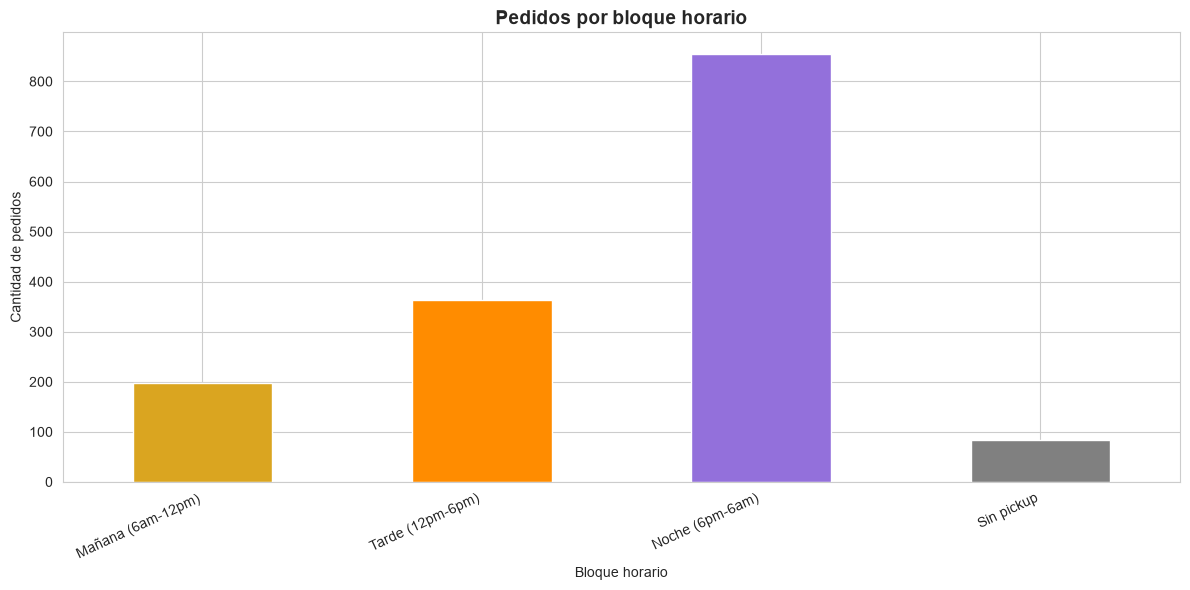

In [43]:
# Entregas por bloque horario
time_block_order = ["Mañana (6am-12pm)", "Tarde (12pm-6pm)", "Noche (6pm-6am)", "Sin pickup"]
time_block_counts = runner_delivery_details["time_block"].value_counts().reindex(time_block_order, fill_value=0)

display(time_block_counts.rename_axis("time_block").reset_index(name="cantidad"))

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
time_block_counts.plot(kind="bar", ax=ax, color=["goldenrod", "darkorange", "mediumpurple", "gray"])
ax.set_title("Pedidos por bloque horario", fontsize=14, fontweight="bold")
ax.set_xlabel("Bloque horario")
ax.set_ylabel("Cantidad de pedidos")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

,topping_name,cantidad_pedida
0,Tomato Sauce,2101
1,Mozzarella,1937
2,Pepperoni,866
3,Olives,722
4,Onion,504
5,Mushroom,504
6,Bell Pepper,504
7,Bacon,468
8,Beef,468
9,BBQ Sauce,278


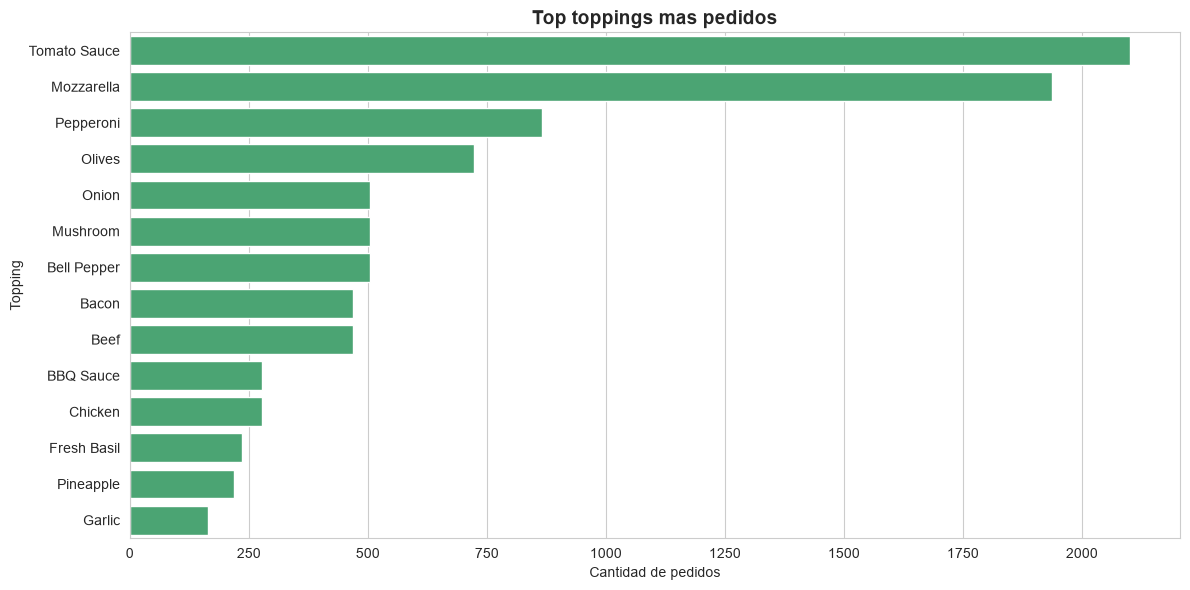

In [44]:
# Top toppings pedidos segun la receta base de cada pizza
toppings_mas_pedidos = (
    orders_toppings_detail["topping_name"]
    .value_counts()
    .rename_axis("topping_name")
    .reset_index(name="cantidad_pedida")
)

display(toppings_mas_pedidos)

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
sns.barplot(
    data=toppings_mas_pedidos,
    x="cantidad_pedida",
    y="topping_name",
    ax=ax,
    color="mediumseagreen",
)
ax.set_title("Top toppings mas pedidos", fontsize=14, fontweight="bold")
ax.set_xlabel("Cantidad de pedidos")
ax.set_ylabel("Topping")
plt.tight_layout()
plt.show()

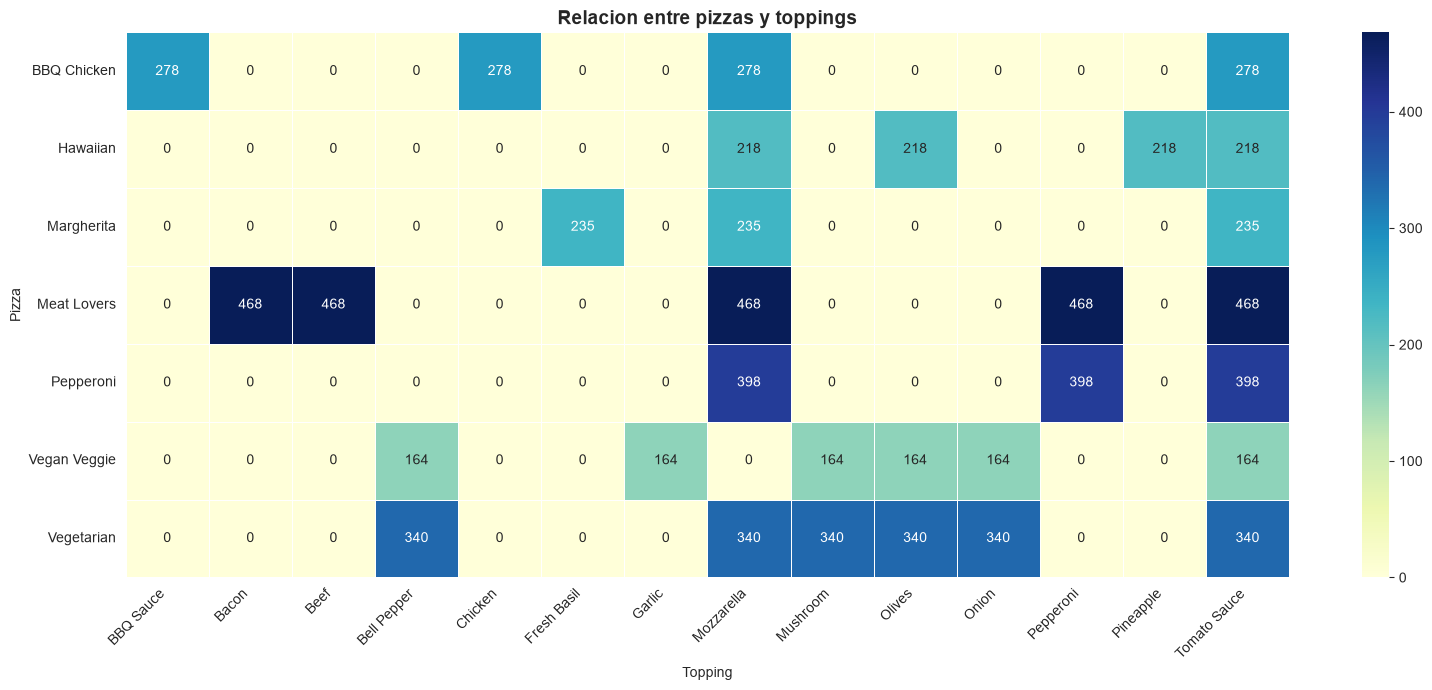

In [45]:
# Mapa de relacion entre pizzas y toppings de receta
pizza_topping_matrix = pd.crosstab(
    orders_toppings_detail["pizza_name"],
    orders_toppings_detail["topping_name"],
)

fig, ax = plt.subplots(1, 1, figsize=(16, 7))
sns.heatmap(
    pizza_topping_matrix,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Relacion entre pizzas y toppings", fontsize=14, fontweight="bold")
ax.set_xlabel("Topping")
ax.set_ylabel("Pizza")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

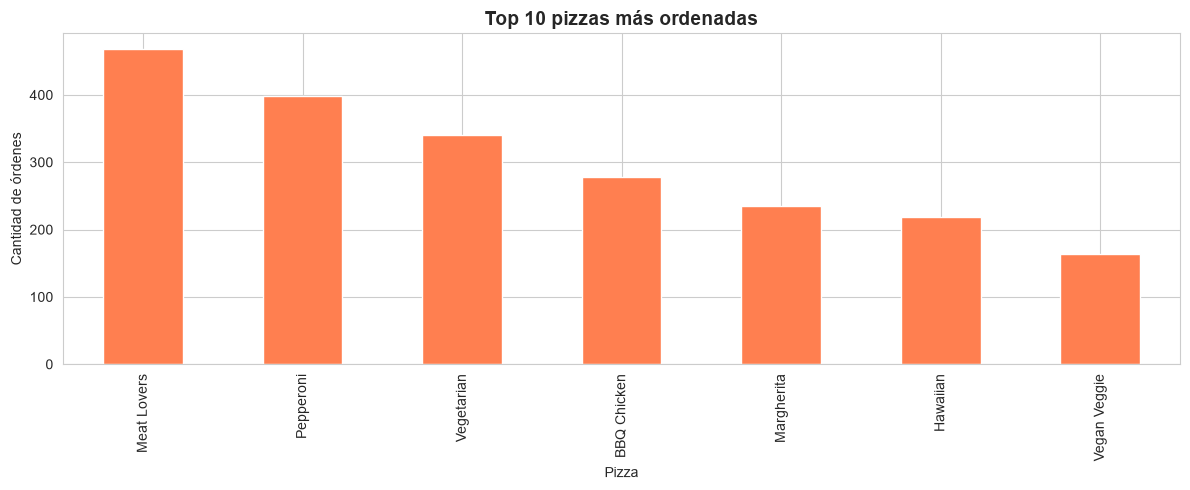

In [46]:
# 2. Pizzas más ordenadas
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
orders_with_pizza_names['pizza_name'].value_counts().head(10).plot(kind='bar', ax=ax, color='coral')
ax.set_title('Top 10 pizzas más ordenadas', fontsize=14, fontweight='bold')
ax.set_xlabel('Pizza')
ax.set_ylabel('Cantidad de órdenes')
plt.tight_layout()
plt.show()

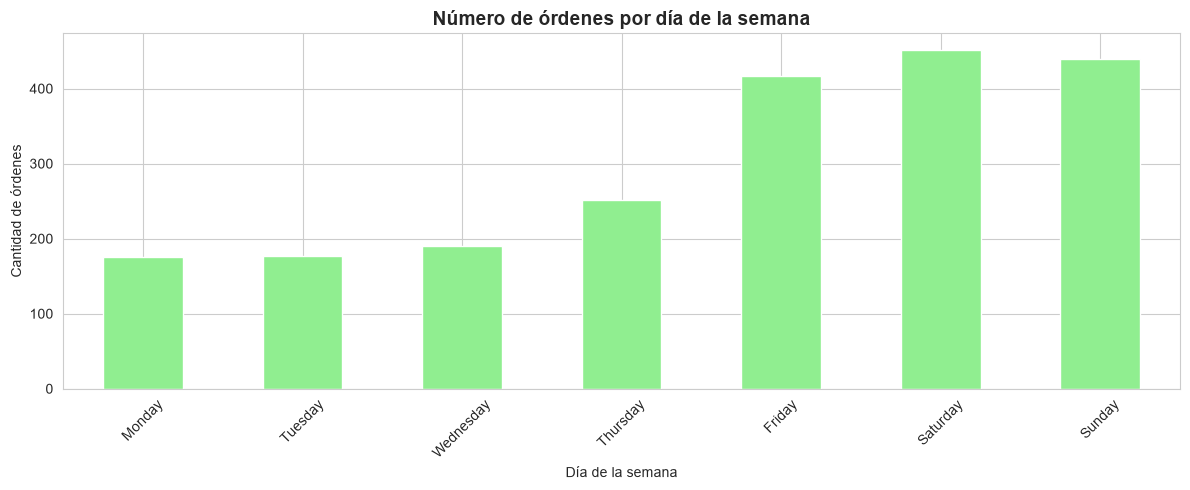

In [47]:
# 3. Órdenes por día de la semana
customer_orders['order_date'] = pd.to_datetime(customer_orders['order_date'])
customer_orders['day_of_week'] = customer_orders['order_date'].dt.day_name()

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
orders_by_day = customer_orders['day_of_week'].value_counts().reindex(day_order)
orders_by_day.plot(kind='bar', ax=ax, color='lightgreen')
ax.set_title('Número de órdenes por día de la semana', fontsize=14, fontweight='bold')
ax.set_xlabel('Día de la semana')
ax.set_ylabel('Cantidad de órdenes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

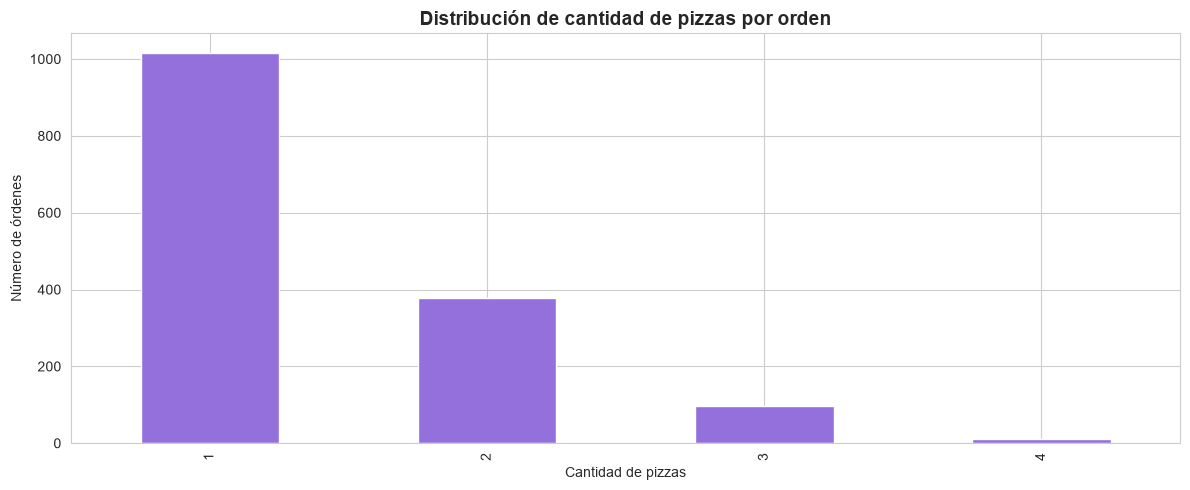

In [48]:
# 4. Distribución de cantidad de pizzas por orden
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
pizzas_por_orden = customer_orders.groupby('order_id').size()
pizzas_por_orden.value_counts().sort_index().plot(kind='bar', ax=ax, color='mediumpurple')
ax.set_title('Distribución de cantidad de pizzas por orden', fontsize=14, fontweight='bold')
ax.set_xlabel('Cantidad de pizzas')
ax.set_ylabel('Número de órdenes')
plt.tight_layout()
plt.show()

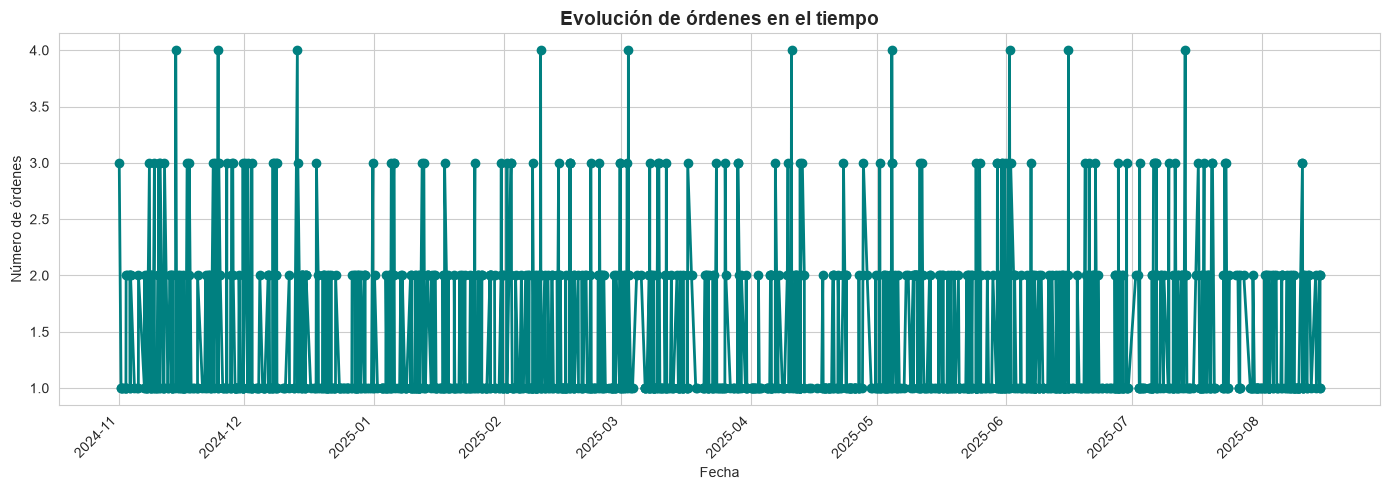

In [49]:
# 5. Órdenes por fecha (tendencia temporal)
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
orders_by_date = customer_orders.groupby('order_date').size()
orders_by_date.plot(ax=ax, color='teal', linewidth=2, marker='o')
ax.set_title('Evolución de órdenes en el tiempo', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Número de órdenes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()